# Calibration tests

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"     # agama
os.environ["MKL_NUM_THREADS"] = "1"     # numpy, scipy
os.environ["OPENBLAS_NUM_THREADS"] = "1"    # numpy
os.environ["NUMEXPR_NUM_THREADS"] = "1"     # pandas

import agama
import torch 
import numpy as np
from scipy import integrate
# from scipy.stats import wasserstein_distance_nd
from astropy import units as u

from sbi.utils import BoxUniform

from sbi.inference import SNLE, simulate_for_sbi, prepare_for_sbi


from sbi.utils import likelihood_nn

from sklearn.metrics import mean_squared_error, r2_score

import pandas as pd
import pickle
import matplotlib.pyplot as plt
from galaxy_generation import generate_galaxy_multiple, transform_params, _generate_galaxy
from prior_generation import generate_prior
from standardization import standardize
from object_handler import load_csv, load_pickle, save_csv, load_galaxies, load_h5
from model import prep_data
import h5py
# from wasserstein_distance_nd import wasserstein_distance_nd 
import corner
from tarp import get_tarp_coverage

torch.set_num_threads(1)


## Data prepping

In [2]:
samples = np.asarray(load_pickle("./model_8/3d/samples.pkl"))
raw_truth = load_h5("./model_8/3d/test_theta.h5", "theta", "ndarray")[:, :8]
_, k = np.unique(raw_truth, axis=0, return_index=True)
k = np.sort(k)
truth = raw_truth[k]

## Rank-based

In [3]:
y = np.sum(samples < truth[:, np.newaxis, :], axis=1)

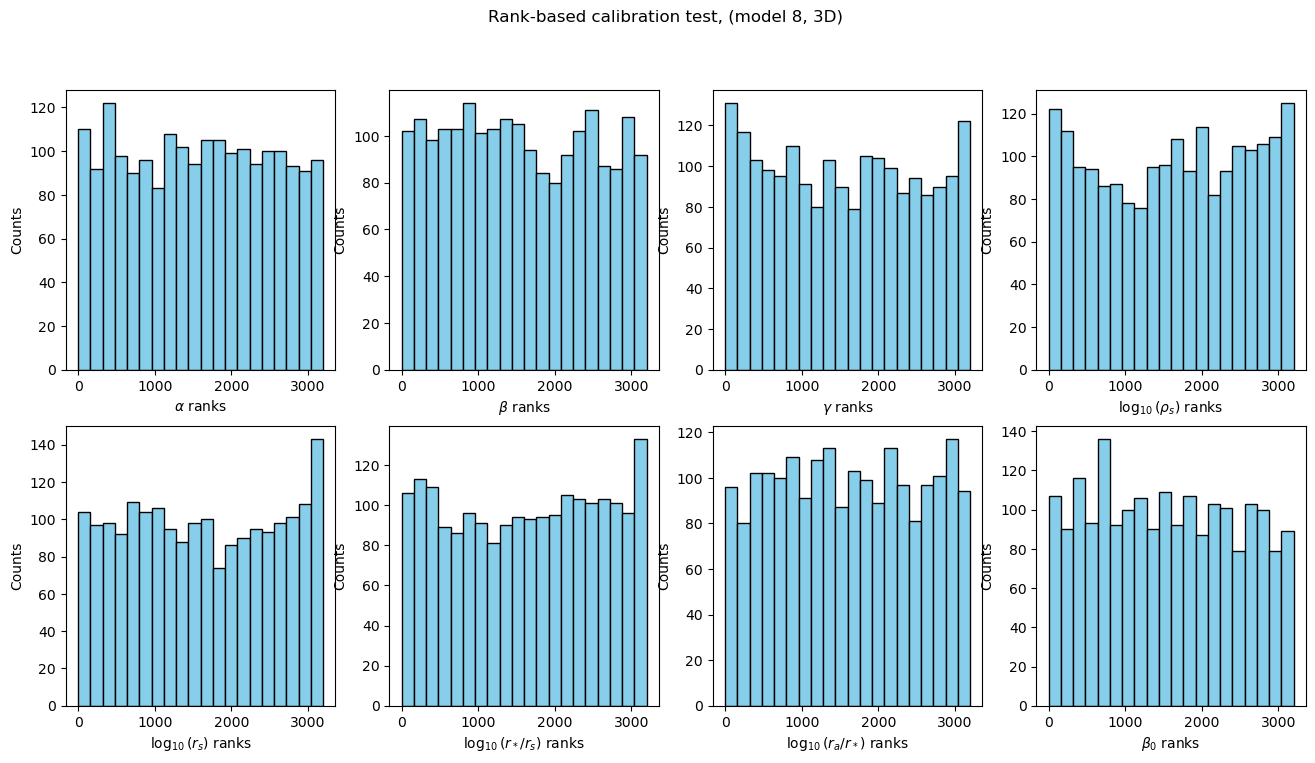

In [4]:
name_list = [
        r"$\alpha$", 
        r"$\beta$", 
        r"$\gamma$",
        r"$\log_{10} (\rho _s)$",
        r"$\log_{10}(r_s)$", 
        r"$\log_{10}(r_* / r_s)$", 
        r"$\log_{10}(r_a / r_*)$", 
        r"$\beta_0$"
        ]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.hist(y[:, i], bins=20, range=(0, 3200), edgecolor='black', color='skyblue')
    ax.set_xlabel(name_list[i] + " ranks")
    ax.set_ylabel("Counts")
    
plt.suptitle("Rank-based calibration test, (model 8, 3D)")
plt.show()

## Tarp

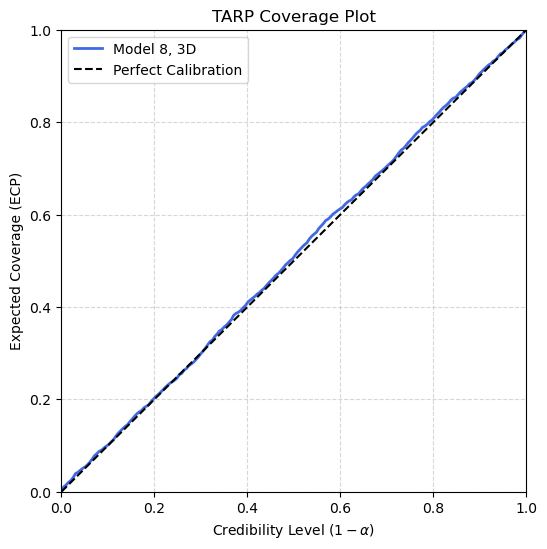

In [5]:
samples_transposed = np.transpose(samples, (1, 0, 2))

ecp, alpha = get_tarp_coverage(
    samples=samples_transposed, 
    theta=truth, 
    references="random", 
    metric="euclidean"
)


plt.figure(figsize=(6, 6))
plt.plot(alpha, ecp, label="Model 8, 3D", color="royalblue", lw=2)
plt.plot([0, 1], [0, 1], label="Perfect Calibration", color="black", linestyle="--")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Credibility Level ($1 - \\alpha$)")
plt.ylabel("Expected Coverage (ECP)")
plt.title("TARP Coverage Plot")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## Mira

In [6]:
import torch
from tqdm import tqdm

# Minimal placeholder for get_device() if not already defined in your environment
def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def mira(truth: torch.Tensor,
          posterior: torch.Tensor,
          num_runs: int = 100,
          norm: bool = False,
          center_choice: torch.Tensor = None,
          reference_choice: torch.Tensor = None,
          disable_tqdm: bool = False,
          device: torch.device = None
          ) -> (torch.Tensor, torch.Tensor):
    """
    Monte Carlo estimation of predictive probabilities, calibration, and per-model normalized counts.
    """
    device = device or get_device()
    truth = truth.to(device)
    posterior = posterior.to(device)

    # Shapes
    M, T, S, q = posterior.shape
    if truth.shape != (T, q):
        raise ValueError(f"Expected truth shape {(T, q)}, got {tuple(truth.shape)}")

    # Min-max normalization
    if norm:
        min_val = truth.min(dim=0, keepdim=True).values
        max_val = truth.max(dim=0, keepdim=True).values
        range_val = max_val - min_val + 1e-8  # avoid divide by zero

        truth = (truth - min_val) / range_val
        posterior = (posterior - min_val) / range_val

    # Constants
    N = S - 1
    max_val = (N + 1) / (N + 2)

    # Pre-allocate
    total_score = torch.zeros((num_runs, M), device=device)
    tqdm_iter = range(num_runs) if disable_tqdm else tqdm(range(num_runs), desc="Mira MC runs")
    
    for run in tqdm_iter:
        # 1. Random centers ~ U[0,1]^q
        if center_choice is not None:
            centers = center_choice
        else:
            centers = torch.rand((T, q), device=device)

        # 2. Distances (M, T, S)
        dists = torch.norm(centers[None, :, None, :] - posterior, dim=3)

        # 3. Random radius per (M, T)
        if reference_choice is not None:
            ref_dists = torch.norm(centers - reference_choice, dim=1)  # (T,)
            radii = ref_dists.unsqueeze(0).expand(M, -1) + 1e-12       # (M, T)
            masked_dists = dists  # FIXED: define masked_dists when reference_choice is active
        else:
            rand_idx = torch.randint(0, S, (M, T), device=device)
            m_idx = torch.arange(M, device=device)[:, None]
            t_idx = torch.arange(T, device=device)[None, :]
            radii = dists[m_idx, t_idx, rand_idx]
            mask = torch.ones((M, T, S), dtype=torch.bool, device=device)
            mask[m_idx, t_idx, rand_idx] = False
            masked_dists = dists.masked_fill(~mask, float('inf'))

        # 4. Truth distances
        true_dists = torch.norm(centers - truth, dim=1)       # (T,)
        k = (true_dists[None, :] <= radii).float()            # (M, T)

        # 5. Counts per radius
        counts = (masked_dists < radii.unsqueeze(2)).sum(dim=2)

        # 6. Predictive probability
        prob_in = (counts + 1) / (N + 2)
        prob_out = (N - counts + 1) / (N + 2)
        prob = prob_in * k + prob_out * (1 - k)

        # 7. Calibration
        calib = prob / max_val

        # 8. Aggregate
        total_score[run] = calib.mean(dim=1)

    mean_score = total_score.mean(dim=0)
    std_score = total_score.std(dim=0, unbiased=True)

    return mean_score, std_score

# ==========================================
# How to run on your actual data:
# ==========================================

# 1. Prepare your tensors (replacing these placeholders with your loaded variables)
my_truth = torch.randn(1979, 8)       # Shape (1979, 8)
my_samples = torch.randn(1979, 3200, 8)  # Shape (1979, 3200, 8)

# 2. Unsqueeze samples to add the model (M) dimension: (1, 1979, 3200, 8)
my_posterior = my_samples.unsqueeze(0)

# 3. Call the function (enabling normalization is recommended for dimensional parity)
mean_score, std_score = mira(
    truth=my_truth,
    posterior=my_posterior,
    num_runs=100,
    norm=True
)

# 4. Extract results
# Because M=1, mean_score and std_score are 1D tensors of size 1.
print(f"MIRA Mean Score: {mean_score.item():.5f}")
print(f"MIRA Standard Deviation: {std_score.item():.5f}")

Mira MC runs: 100%|██████████| 100/100 [00:19<00:00,  5.19it/s]


MIRA Mean Score: 0.66591
MIRA Standard Deviation: 0.00537
